In [22]:
import os
os.environ["GDAL_PAM_ENABLED"] = "NO"
import numpy as np
from glob import glob
from spectral.io import envi
import matplotlib.pyplot as plt

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import from_bounds
from rasterio.windows import transform as window_transform
from shapely.geometry import box

from isofit.utils.skyview import skyview

In [29]:
%matplotlib widget

In [2]:
home = '/store/carroll/col/data/2018/'

fp_dsm = os.path.join(home, 'skyview', 'dsm_1m_mosaic_bbox_buf1250m')
dsm = envi.open(fp_dsm+'.hdr')

In [15]:
fp = glob(os.path.join(home, 'raw/rmbl', '*', f'{flight}_rdn_ort'))[0]

rdn = envi.open(fp+'.hdr')

In [24]:
# clip dsm per flightline (buffered by 1.5 km)

flight = 'NIS01_20180612_155442'

fp = glob(os.path.join(home, 'raw/rmbl', '*', f'{flight}_rdn_ort'))[0]

fp_out = os.path.join(home, 'skyview', f'{flight}_dsm_buf')

# buffer flightline by 1.5km
with rasterio.open(fp) as ref:
    ref_bounds = ref.bounds
    ref_poly = box(ref_bounds.left, ref_bounds.bottom, ref_bounds.right, ref_bounds.top)
    ref_poly_buf = ref_poly.buffer(1500)

# clip dsm by buffered poly
with rasterio.open(fp_dsm) as src:
    win = from_bounds(*ref_poly_buf.bounds, transform=src.transform).round_offsets().round_shape() # build a window from bounds, round offsets and shape as necessary
    out_transform = window_transform(win, src.transform)
    data = src.read(window=win) # load data in that window

    out_profile = src.profile.copy()
    out_profile.update({
        'driver': 'ENVI',
        'height': win.height,
        'width': win.width,
        'transform': out_transform
    })

# export
with rasterio.open(fp_out, 'w', **out_profile) as dst:
    dst.write(data)

# now I want to run the above through skyview

# skyview = np.ones(data.shape)
# skyview.shape

# and then clip that skyview raster to 

# with rasterio.open(fp) as ref:
#     ref_profile = ref.profile
#     ref_transform = ref.transform
#     ref_crs = ref.crs
#     ref_shape = (ref.height, ref.width)

# with rasterio.open(fp_dsm) as src:
#     out_array = np.empty(ref_shape, dtype=src.dtypes[0])
#     reproject(
#         source=rasterio.band(src, 1),
#         destination=out_array,
#         src_transform=src.transform,
#         src_crs=src.crs,
#         dst_transform=ref_transform,
#         dst_crs=ref_crs,
#         resampling=Resampling.nearest  # or bilinear/cubic for continuous data
#     )

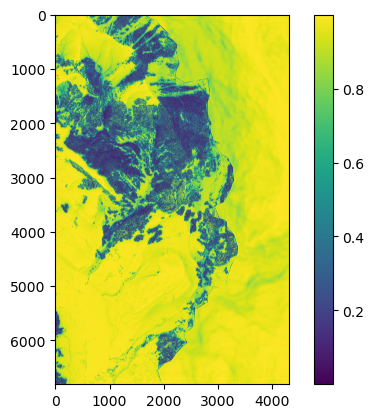

In [26]:
# NIS01_20180612_155442_skyview

# hmm the 1m resolution makes the forest canoopy have pretty low skyview... is that accurate?
fp = '/store/carroll/col/data/2018/skyview/sky_view_factor.hdr'
tmp = envi.open(fp).open_memmap()

fig = plt.figure()
plt.imshow(tmp[...,0])
plt.colorbar()
plt.show()

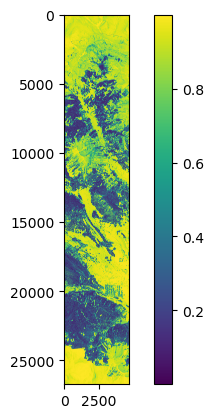

In [27]:
# NIS01_20180616_162542_skyview
# hmm the 1m resolution makes the forest canoopy have pretty low skyview... is that accurate?
fp = '/store/carroll/col/data/2018/skyview/sky_view_factor.hdr'
tmp = envi.open(fp).open_memmap()

fig = plt.figure()
plt.imshow(tmp[...,0])
plt.colorbar()
plt.show()

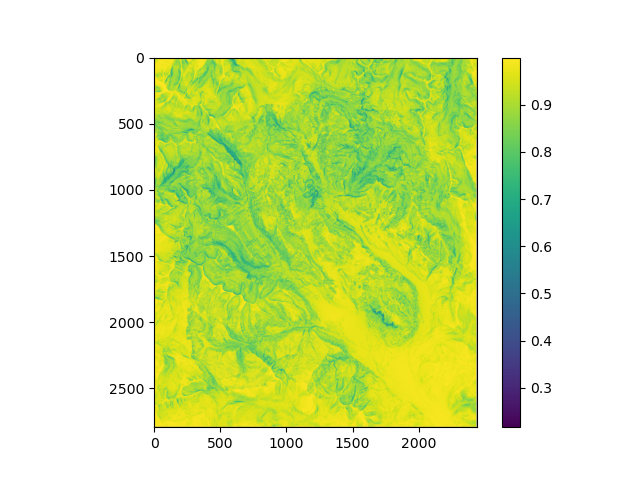

In [30]:
# whole 10m skyview

fp = '/store/carroll/col/data/2018/skyview/sky_view_factor.hdr'
tmp = envi.open(fp).open_memmap()

fig = plt.figure()
plt.imshow(tmp[...,0])
plt.colorbar()
plt.show()